# CS461 讽刺检测项目

这个笔记本用于所有实验：数据探索、模型训练、评估

**流程**：
1. 数据探索
2. 训练基线模型（逻辑回归 + TF-IDF）
3. 尝试进阶模型（SVM、LSTM等）
4. 保存最佳模型
5. 记录所有结果（用于报告）


## 第一步：加载库和数据


In [27]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 加载数据
train_df = pd.read_csv('train.csv')
valid_df = pd.read_csv('valid.csv')
test_df = pd.read_csv('test.csv')

print(f"Training set: {len(train_df)} samples")
print(f"Validation set: {len(valid_df)} samples")
print(f"Test set: {len(test_df)} samples")

# 查看前几行
train_df.head()


Training set: 21464 samples
Validation set: 716 samples
Test set: 966 samples


,text,label
0,states slow to shut down weak teacher educatio...,0
1,drone places fresh kill on steps of white house,1
2,report: majority of instances of people gettin...,1
3,"sole remaining lung filled with rich, satisfyi...",1
4,the gop's stockholm syndrome,0


Label Distribution:
label
0    11248
1    10216
Name: count, dtype: int64

Sarcasm ratio: 47.60%


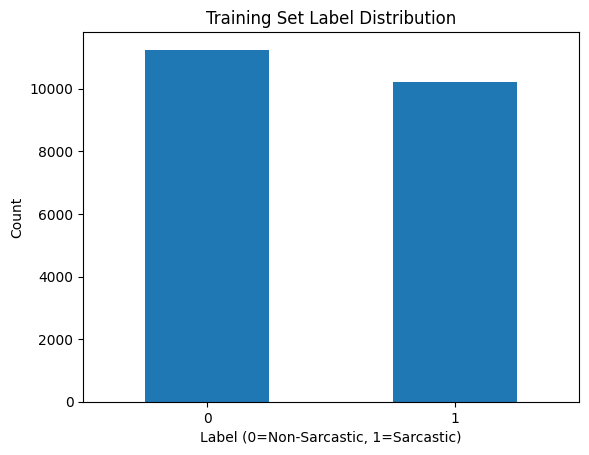


Average text length: 62.3 characters

Sarcastic examples:
  - drone places fresh kill on steps of white house
  - report: majority of instances of people getting lives back on track occur immediately after visit to buffalo wild wings
  - sole remaining lung filled with rich, satisfying flavor

Non-sarcastic examples:
  - states slow to shut down weak teacher education programs
  - the gop's stockholm syndrome
  - trump's game plan


In [19]:
# 标签分布
print("Label Distribution:")
print(train_df['label'].value_counts())
print(f"\nSarcasm ratio: {train_df['label'].mean()*100:.2f}%")

# 可视化
train_df['label'].value_counts().plot(kind='bar')
plt.title('Training Set Label Distribution')
plt.xlabel('Label (0=Non-Sarcastic, 1=Sarcastic)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# 文本长度
train_df['length'] = train_df['text'].str.len()
print(f"\nAverage text length: {train_df['length'].mean():.1f} characters")

# 查看样例
print("\nSarcastic examples:")
for text in train_df[train_df['label']==1]['text'].head(3):
    print(f"  - {text}")
    
print("\nNon-sarcastic examples:")
for text in train_df[train_df['label']==0]['text'].head(3):
    print(f"  - {text}")


## 第三步：训练基线模型 - 逻辑回归 + TF-IDF

目标：F1 > 0.70


In [5]:
# 简单预处理：转小写
train_texts = train_df['text'].str.lower()
valid_texts = valid_df['text'].str.lower()
test_texts = test_df['text'].str.lower()

# TF-IDF特征提取
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train = vectorizer.fit_transform(train_texts)
X_valid = vectorizer.transform(valid_texts)
X_test = vectorizer.transform(test_texts)

print(f"Feature dimension: {X_train.shape[1]}")

# 训练逻辑回归
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, train_df['label'])

# 验证集评估
y_pred_valid = model.predict(X_valid)
print("\nValidation Set Performance:")
print(classification_report(valid_df['label'], y_pred_valid))
print(f"F1 Score: {f1_score(valid_df['label'], y_pred_valid):.4f}")

# 测试集评估
y_pred_test = model.predict(X_test)
print("\nTest Set Performance:")
print(classification_report(test_df['label'], y_pred_test))
print(f"Accuracy:  {accuracy_score(test_df['label'], y_pred_test):.4f}")
print(f"F1 Score:  {f1_score(test_df['label'], y_pred_test):.4f}")


Feature dimension: 5000

Validation Set Performance:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       360
           1       0.83      0.83      0.83       356

    accuracy                           0.83       716
   macro avg       0.83      0.83      0.83       716
weighted avg       0.83      0.83      0.83       716

F1 Score: 0.8315

Test Set Performance:
              precision    recall  f1-score   support

           0       0.85      0.84      0.85       526
           1       0.81      0.82      0.82       440

    accuracy                           0.83       966
   macro avg       0.83      0.83      0.83       966
weighted avg       0.83      0.83      0.83       966

Accuracy:  0.8323
F1 Score:  0.8163



Confusion Matrix (Test Set):
[[444  82]
 [ 80 360]]

True Negative (TN): 444 | False Positive (FP): 82
False Negative (FN): 80 | True Positive (TP): 360


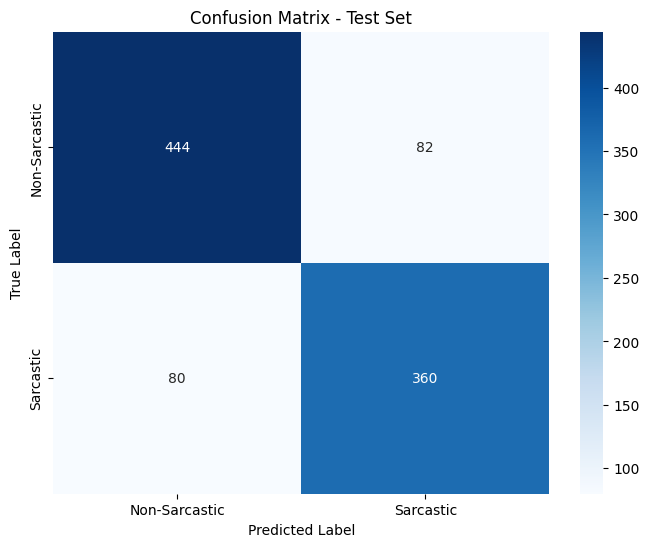


✅ Manual Verification:
Accuracy: 0.8323
Precision (Sarcastic class): 0.8145
Recall (Sarcastic class): 0.8182
F1 (Sarcastic class): 0.8163


In [6]:
# 验证：查看混淆矩阵
from sklearn.metrics import confusion_matrix

# 测试集混淆矩阵
cm = confusion_matrix(test_df['label'], y_pred_test)
print("\nConfusion Matrix (Test Set):")
print(cm)
print(f"\nTrue Negative (TN): {cm[0,0]} | False Positive (FP): {cm[0,1]}")
print(f"False Negative (FN): {cm[1,0]} | True Positive (TP): {cm[1,1]}")

# 可视化
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Sarcastic', 'Sarcastic'],
            yticklabels=['Non-Sarcastic', 'Sarcastic'])
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 计算详细指标
print("\n✅ Manual Verification:")
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision_class1 = tp / (tp + fp)
recall_class1 = tp / (tp + fn)
f1_class1 = 2 * (precision_class1 * recall_class1) / (precision_class1 + recall_class1)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (Sarcastic class): {precision_class1:.4f}")
print(f"Recall (Sarcastic class): {recall_class1:.4f}")
print(f"F1 (Sarcastic class): {f1_class1:.4f}")


## 第四步：保存模型

保存最佳模型用于最终提交


In [ ]:
import joblib

# 保存模型和向量化器
joblib.dump(model, 'models/model_weights.pkl')
joblib.dump(vectorizer, 'models/vectorizer.pkl')

print("✅ Model saved to models/ folder")


---

## 🔄 下一步改进方向

在下面添加新的代码单元格尝试：

1. **更多模型**：
   - SVM
   - Random Forest
   - Naive Bayes
   
2. **更好的特征**：
   - Word2Vec / GloVe
   - 不同的n-gram组合
   - 手工特征（标点、大写等）

3. **深度学习**：
   - LSTM
   - BiLSTM
   - CNN

4. **集成方法**：
   - 投票集成
   - Stacking

记得记录所有实验结果用于报告！


---

## 📊 结果记录（用于报告）


In [8]:
# 实验结果记录（复制到报告）
results = {
    'Model': 'Logistic Regression + TF-IDF',
    'Features': 'unigram + bigram, max_features=5000',
    'Preprocessing': 'lowercase',
    'Validation F1': f"{f1_score(valid_df['label'], y_pred_valid):.4f}",
    'Test Accuracy': f"{accuracy_score(test_df['label'], y_pred_test):.4f}",
    'Test Precision': f"{precision_class1:.4f}",
    'Test Recall': f"{recall_class1:.4f}",
    'Test F1': f"{f1_class1:.4f}"
}

print("="*60)
print("BASELINE MODEL RESULTS (For Report)")
print("="*60)
for key, value in results.items():
    print(f"{key:20s}: {value}")
print("="*60)


BASELINE MODEL RESULTS (For Report)
Model               : Logistic Regression + TF-IDF
Features            : unigram + bigram, max_features=5000
Preprocessing       : lowercase
Validation F1       : 0.8315
Test Accuracy       : 0.8323
Test Precision      : 0.8145
Test Recall         : 0.8182
Test F1             : 0.8163


---

## 🔧 超参数调优实验


In [9]:
# 方法1：手动尝试不同参数组合
from sklearn.metrics import f1_score
import time

# 定义要测试的参数组合
experiments = [
    # 实验1: 增加特征数量
    {'name': 'More Features', 
     'vectorizer': TfidfVectorizer(max_features=10000, ngram_range=(1,2)),
     'model': LogisticRegression(max_iter=1000, random_state=42)},
    
    # 实验2: 添加trigram
    {'name': 'Trigram', 
     'vectorizer': TfidfVectorizer(max_features=5000, ngram_range=(1,3)),
     'model': LogisticRegression(max_iter=1000, random_state=42)},
    
    # 实验3: 更强的正则化
    {'name': 'Stronger Regularization', 
     'vectorizer': TfidfVectorizer(max_features=5000, ngram_range=(1,2)),
     'model': LogisticRegression(max_iter=1000, random_state=42, C=0.5)},
    
    # 实验4: 添加过滤和缩放
    {'name': 'With min_df & sublinear_tf', 
     'vectorizer': TfidfVectorizer(max_features=7000, ngram_range=(1,2), min_df=3, sublinear_tf=True),
     'model': LogisticRegression(max_iter=1000, random_state=42, C=1.0)},
    
    # 实验5: 组合优化
    {'name': 'Combined Optimization', 
     'vectorizer': TfidfVectorizer(max_features=8000, ngram_range=(1,3), min_df=2, max_df=0.95, sublinear_tf=True),
     'model': LogisticRegression(max_iter=1000, random_state=42, C=2.0)},
]

# 运行所有实验
print("="*80)
print("HYPERPARAMETER TUNING EXPERIMENTS")
print("="*80)

results_list = []

for exp in experiments:
    start_time = time.time()
    
    # 特征提取
    vec = exp['vectorizer']
    X_train_exp = vec.fit_transform(train_texts)
    X_valid_exp = vec.transform(valid_texts)
    X_test_exp = vec.transform(test_texts)
    
    # 训练
    mdl = exp['model']
    mdl.fit(X_train_exp, train_df['label'])
    
    # 评估
    y_pred_valid_exp = mdl.predict(X_valid_exp)
    y_pred_test_exp = mdl.predict(X_test_exp)
    
    valid_f1 = f1_score(valid_df['label'], y_pred_valid_exp)
    test_f1 = f1_score(test_df['label'], y_pred_test_exp)
    test_acc = accuracy_score(test_df['label'], y_pred_test_exp)
    
    elapsed = time.time() - start_time
    
    # 记录结果
    results_list.append({
        'Experiment': exp['name'],
        'Valid F1': valid_f1,
        'Test F1': test_f1,
        'Test Acc': test_acc,
        'Time (s)': elapsed
    })
    
    print(f"\n{exp['name']:35s} | Valid F1: {valid_f1:.4f} | Test F1: {test_f1:.4f} | Test Acc: {test_acc:.4f} | Time: {elapsed:.1f}s")

print("\n" + "="*80)
print("SUMMARY - Sorted by Test F1")
print("="*80)

# 转换为DataFrame并排序
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values('Test F1', ascending=False)
print(results_df.to_string(index=False))

# 找出最佳配置
best_exp = results_df.iloc[0]
print(f"\n🏆 Best Configuration: {best_exp['Experiment']}")
print(f"   Test F1: {best_exp['Test F1']:.4f}")
print(f"   Improvement: {(best_exp['Test F1'] - 0.8163)*100:.2f} percentage points")


HYPERPARAMETER TUNING EXPERIMENTS

More Features                       | Valid F1: 0.8305 | Test F1: 0.8318 | Test Acc: 0.8468 | Time: 0.4s

Trigram                             | Valid F1: 0.8315 | Test F1: 0.8127 | Test Acc: 0.8292 | Time: 0.6s

Stronger Regularization             | Valid F1: 0.8280 | Test F1: 0.8157 | Test Acc: 0.8302 | Time: 0.3s

With min_df & sublinear_tf          | Valid F1: 0.8300 | Test F1: 0.8202 | Test Acc: 0.8375 | Time: 0.4s

Combined Optimization               | Valid F1: 0.8315 | Test F1: 0.8285 | Test Acc: 0.8458 | Time: 0.6s

SUMMARY - Sorted by Test F1
                Experiment  Valid F1  Test F1  Test Acc  Time (s)
             More Features  0.830508 0.831818  0.846791  0.352068
     Combined Optimization  0.831461 0.828539  0.845756  0.616205
With min_df & sublinear_tf  0.830028 0.820160  0.837474  0.350285
   Stronger Regularization  0.827972 0.815730  0.830228  0.324972
                   Trigram  0.831461 0.812713  0.829193  0.622573

🏆 Best Con

### 方法2：使用GridSearchCV自动搜索最佳参数（更系统）


In [10]:
# 使用GridSearchCV进行自动调优（可选，会比较慢）
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# 创建Pipeline（把特征提取和模型训练串联）
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# 定义参数网格
param_grid = {
    # TF-IDF参数
    'tfidf__max_features': [5000, 7000, 10000],
    'tfidf__ngram_range': [(1, 2), (1, 3)],
    'tfidf__min_df': [2, 3],
    'tfidf__sublinear_tf': [True, False],
    
    # 逻辑回归参数
    'clf__C': [0.5, 1.0, 2.0],
}

# 创建GridSearchCV
print("Starting Grid Search... (This may take 5-10 minutes)")
print(f"Total combinations to test: {3 * 2 * 2 * 2 * 3} = 72")

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,                    # 5折交叉验证
    scoring='f1',            # 优化F1分数
    n_jobs=-1,               # 使用所有CPU核心
    verbose=1                # 显示进度
)

# 在训练集上搜索
grid_search.fit(train_texts, train_df['label'])

# 显示最佳参数
print("\n" + "="*80)
print("GRID SEARCH RESULTS")
print("="*80)
print(f"\nBest parameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param:30s}: {value}")

print(f"\nBest cross-validation F1 score: {grid_search.best_score_:.4f}")

# 在测试集上评估
best_model = grid_search.best_estimator_
y_pred_test_grid = best_model.predict(test_texts)
test_f1_grid = f1_score(test_df['label'], y_pred_test_grid)
test_acc_grid = accuracy_score(test_df['label'], y_pred_test_grid)

print(f"\nTest Set Performance with Best Model:")
print(f"  F1 Score:  {test_f1_grid:.4f}")
print(f"  Accuracy:  {test_acc_grid:.4f}")
print(f"  Improvement over baseline: {(test_f1_grid - 0.8163)*100:.2f} percentage points")


Starting Grid Search... (This may take 5-10 minutes)
Total combinations to test: 72 = 72
Fitting 5 folds for each of 72 candidates, totalling 360 fits

GRID SEARCH RESULTS

Best parameters found:
  clf__C                        : 2.0
  tfidf__max_features           : 10000
  tfidf__min_df                 : 3
  tfidf__ngram_range            : (1, 2)
  tfidf__sublinear_tf           : False

Best cross-validation F1 score: 0.8354

Test Set Performance with Best Model:
  F1 Score:  0.8311
  Accuracy:  0.8468
  Improvement over baseline: 1.48 percentage points


---

## 🧠 深度学习模型：BiLSTM

使用双向LSTM捕获文本的上下文信息，可能比TF-IDF更好地理解讽刺


In [7]:
# 安装tensorflow（如果还没有）
# !pip install tensorflow --quiet

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

# 设置随机种子
tf.random.set_seed(42)
np.random.seed(42)


TensorFlow version: 2.20.0
GPU available: []


### 步骤1：文本序列化和填充


In [8]:
# 参数设置
MAX_WORDS = 10000        # 词汇表大小
MAX_LEN = 100            # 序列最大长度
EMBEDDING_DIM = 128      # 词嵌入维度

# 创建Tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['text'])

# 转换文本为序列
X_train_seq = tokenizer.texts_to_sequences(train_df['text'])
X_valid_seq = tokenizer.texts_to_sequences(valid_df['text'])
X_test_seq = tokenizer.texts_to_sequences(test_df['text'])

# 填充序列到相同长度
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_valid_pad = pad_sequences(X_valid_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

# 标签
y_train_lstm = train_df['label'].values
y_valid_lstm = valid_df['label'].values
y_test_lstm = test_df['label'].values

print(f"Vocabulary size: {len(tokenizer.word_index)}")
print(f"Training sequences shape: {X_train_pad.shape}")
print(f"Validation sequences shape: {X_valid_pad.shape}")
print(f"Test sequences shape: {X_test_pad.shape}")

# 查看样例
print(f"\nExample text: {train_df['text'].iloc[0]}")
print(f"Tokenized: {X_train_seq[0][:20]}...")
print(f"Padded shape: {X_train_pad[0].shape}")


Vocabulary size: 26814
Training sequences shape: (21464, 100)
Validation sequences shape: (716, 100)
Test sequences shape: (966, 100)

Example text: states slow to shut down weak teacher education programs
Tokenized: [462, 2464, 2, 1086, 73, 2465, 410, 566, 2466]...
Padded shape: (100,)


### 步骤2：构建BiLSTM模型


In [12]:
# 构建BiLSTM模型
def build_bilstm_model():
    model = Sequential([
        # 词嵌入层
        Embedding(input_dim=MAX_WORDS, 
                  output_dim=EMBEDDING_DIM, 
                  input_length=MAX_LEN,
                  name='embedding'),
        
        # Spatial Dropout (对整个词嵌入向量进行dropout)
        SpatialDropout1D(0.2),
        
        # 双向LSTM层 (捕获前后文信息)
        Bidirectional(LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)),
        
        # 第二层双向LSTM
        Bidirectional(LSTM(32, dropout=0.2, recurrent_dropout=0.2)),
        
        # 全连接层
        Dense(64, activation='relu'),
        Dropout(0.5),
        
        # 输出层 (二分类)
        Dense(1, activation='sigmoid')
    ])
    
    return model

# 创建模型
lstm_model = build_bilstm_model()

# 手动构建模型（指定输入形状）
lstm_model.build(input_shape=(None, MAX_LEN))

# 编译模型
lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

# 显示模型结构
print("="*80)
print("BILSTM MODEL ARCHITECTURE")
print("="*80)
lstm_model.summary()

# 计算参数量
total_params = lstm_model.count_params()
print(f"\nTotal parameters: {total_params:,}")


BILSTM MODEL ARCHITECTURE


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ (None, 100, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 100, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,424,257 (5.43 MB)

 Trainable params: 1,424,257 (5.43 MB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 1,424,257


### 步骤3：训练模型（使用Early Stopping）


In [13]:
# 定义回调函数
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,              # 5个epoch没有改善就停止
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,              # 学习率减半
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# 训练模型
print("="*80)
print("TRAINING BILSTM MODEL")
print("="*80)

history = lstm_model.fit(
    X_train_pad, y_train_lstm,
    validation_data=(X_valid_pad, y_valid_lstm),
    epochs=20,               # 最多20个epoch
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\n✅ Training completed!")


TRAINING BILSTM MODEL
Epoch 1/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 30s 78ms/step - accuracy: 0.7849 - loss: 0.4327 - precision_3: 0.7884 - recall_3: 0.7493 - val_accuracy: 0.8715 - val_loss: 0.3339 - val_precision_3: 0.8548 - val_recall_3: 0.8933 - learning_rate: 0.0010
Epoch 2/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 26s 79ms/step - accuracy: 0.9101 - loss: 0.2284 - precision_3: 0.9051 - recall_3: 0.9062 - val_accuracy: 0.8547 - val_loss: 0.3686 - val_precision_3: 0.8559 - val_recall_3: 0.8511 - learning_rate: 0.0010
Epoch 3/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 26s 79ms/step - accuracy: 0.9453 - loss: 0.1503 - precision_3: 0.9425 - recall_3: 0.9424 - val_accuracy: 0.8506 - val_loss: 0.4599 - val_precision_3: 0.8609 - val_recall_3: 0.8343 - learning_rate: 0.0010
Epoch 4/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.9615 - loss: 0.1079 - precision_3: 0.9606 - recall_3: 0.9588
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
336/336 ━━━━━━━━━━━━━━━━━━━━ 26s 78ms/step

### 步骤4：可视化训练过程


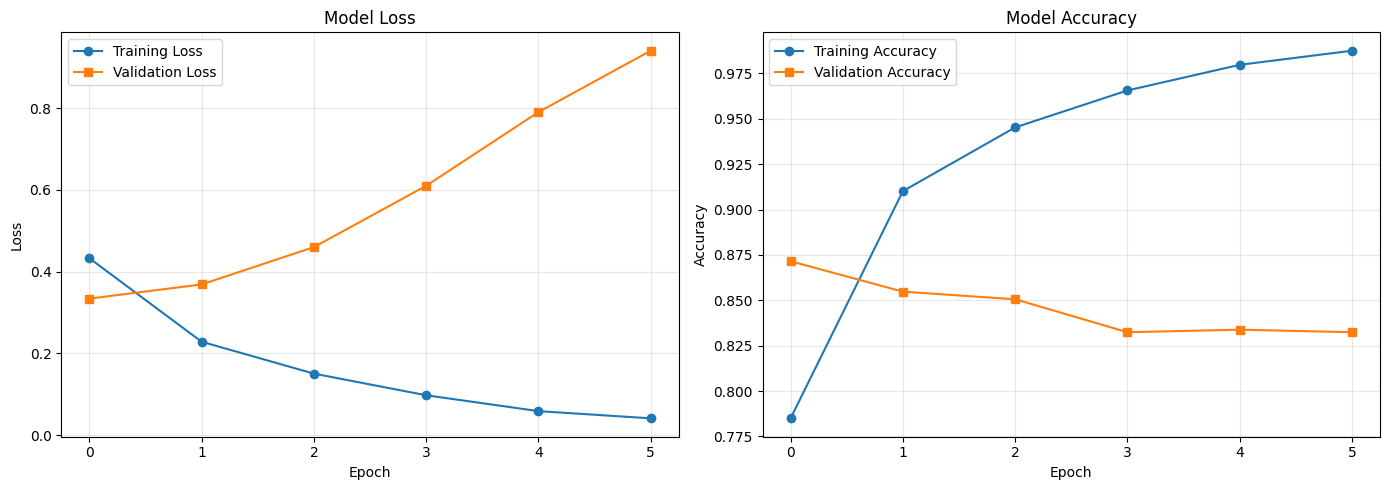


Best epoch: 1
Best validation loss: 0.3339
Best validation accuracy: 0.8715


In [14]:
# 绘制训练历史
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss曲线
axes[0].plot(history.history['loss'], label='Training Loss', marker='o')
axes[0].plot(history.history['val_loss'], label='Validation Loss', marker='s')
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy曲线
axes[1].plot(history.history['accuracy'], label='Training Accuracy', marker='o')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
axes[1].set_title('Model Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 找到最佳epoch
best_epoch = np.argmin(history.history['val_loss']) + 1
best_val_loss = min(history.history['val_loss'])
best_val_acc = max(history.history['val_accuracy'])

print(f"\nBest epoch: {best_epoch}")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Best validation accuracy: {best_val_acc:.4f}")


### 步骤5：评估BiLSTM性能


In [15]:
# 在测试集上预测
y_pred_lstm_prob = lstm_model.predict(X_test_pad, verbose=0)
y_pred_lstm = (y_pred_lstm_prob > 0.5).astype(int).flatten()

# 计算各项指标
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score

lstm_accuracy = accuracy_score(y_test_lstm, y_pred_lstm)
lstm_precision = precision_score(y_test_lstm, y_pred_lstm)
lstm_recall = recall_score(y_test_lstm, y_pred_lstm)
lstm_f1 = f1_score(y_test_lstm, y_pred_lstm)

print("="*80)
print("BILSTM TEST SET PERFORMANCE")
print("="*80)

print("\nDetailed Classification Report:")
print(classification_report(y_test_lstm, y_pred_lstm, 
                          target_names=['Non-Sarcastic', 'Sarcastic']))

print(f"\nTest Set Metrics:")
print(f"  Accuracy:  {lstm_accuracy:.4f}")
print(f"  Precision: {lstm_precision:.4f}")
print(f"  Recall:    {lstm_recall:.4f}")
print(f"  F1 Score:  {lstm_f1:.4f}")

# 与逻辑回归对比
print("\n" + "="*80)
print("COMPARISON WITH LOGISTIC REGRESSION")
print("="*80)
print(f"{'Model':<30s} {'Accuracy':<12s} {'Precision':<12s} {'Recall':<12s} {'F1 Score':<12s}")
print("-"*80)
print(f"{'Logistic Regression':<30s} {0.8323:<12.4f} {0.8145:<12.4f} {0.8182:<12.4f} {0.8163:<12.4f}")
print(f"{'BiLSTM':<30s} {lstm_accuracy:<12.4f} {lstm_precision:<12.4f} {lstm_recall:<12.4f} {lstm_f1:<12.4f}")
print("-"*80)
print(f"{'Improvement':<30s} {lstm_accuracy-0.8323:<+12.4f} {lstm_precision-0.8145:<+12.4f} {lstm_recall-0.8182:<+12.4f} {lstm_f1-0.8163:<+12.4f}")
print(f"{'Improvement (%)':<30s} {(lstm_accuracy-0.8323)/0.8323*100:<+12.2f} {(lstm_precision-0.8145)/0.8145*100:<+12.2f} {(lstm_recall-0.8182)/0.8182*100:<+12.2f} {(lstm_f1-0.8163)/0.8163*100:<+12.2f}")


BILSTM TEST SET PERFORMANCE

Detailed Classification Report:
               precision    recall  f1-score   support

Non-Sarcastic       0.90      0.85      0.87       526
    Sarcastic       0.83      0.89      0.86       440

     accuracy                           0.87       966
    macro avg       0.87      0.87      0.87       966
 weighted avg       0.87      0.87      0.87       966


Test Set Metrics:
  Accuracy:  0.8665
  Precision: 0.8316
  Recall:    0.8864
  F1 Score:  0.8581

COMPARISON WITH LOGISTIC REGRESSION
Model                          Accuracy     Precision    Recall       F1 Score    
--------------------------------------------------------------------------------
Logistic Regression            0.8323       0.8145       0.8182       0.8163      
BiLSTM                         0.8665       0.8316       0.8864       0.8581      
--------------------------------------------------------------------------------
Improvement                    +0.0342      +0.0171      +0

In [ ]:
# 绘制混淆矩阵
cm_lstm = confusion_matrix(y_test_lstm, y_pred_lstm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Non-Sarcastic', 'Sarcastic'],
            yticklabels=['Non-Sarcastic', 'Sarcastic'])
plt.title('BiLSTM - Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nConfusion Matrix:")
print(cm_lstm)
print(f"\nTrue Negative (TN): {cm_lstm[0,0]} | False Positive (FP): {cm_lstm[0,1]}")
print(f"False Negative (FN): {cm_lstm[1,0]} | True Positive (TP): {cm_lstm[1,1]}")


### 步骤6：保存BiLSTM模型


In [ ]:
# 保存模型和tokenizer
import pickle

# 保存Keras模型
lstm_model.save('models/bilstm_model.h5')
print("✅ BiLSTM model saved to models/bilstm_model.h5")

# 保存tokenizer
with open('models/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("✅ Tokenizer saved to models/tokenizer.pkl")

# 保存配置
lstm_config = {
    'max_words': MAX_WORDS,
    'max_len': MAX_LEN,
    'embedding_dim': EMBEDDING_DIM,
    'test_f1': float(lstm_f1),
    'test_accuracy': float(lstm_accuracy)
}

with open('models/lstm_config.pkl', 'wb') as f:
    pickle.dump(lstm_config, f)
print("✅ Config saved to models/lstm_config.pkl")

print("\n🏆 BiLSTM training completed and model saved!")


---

## 🔥 优化版BiLSTM：使用预训练词嵌入（GloVe）

使用预训练的GloVe词向量替代随机初始化的embedding，可以利用大规模语料库学到的语义知识


In [22]:
# 方案1：下载并加载GloVe词向量
# 首先需要下载GloVe（如果还没有）
# !wget http://nlp.stanford.edu/data/glove.6B.zip
# !unzip glove.6B.zip

import numpy as np

# 加载GloVe词向量（使用100维）
def load_glove_embeddings(glove_path='glove.6B.100d.txt', word_index=None, embedding_dim=100):
    """
    加载GloVe预训练词向量
    """
    print("Loading GloVe embeddings...")
    embeddings_index = {}
    
    try:
        with open(glove_path, 'r', encoding='utf-8') as f:
            for line in f:
                values = line.split()
                word = values[0]
                coefs = np.asarray(values[1:], dtype='float32')
                embeddings_index[word] = coefs
        
        print(f"Found {len(embeddings_index)} word vectors.")
        
        # 创建embedding矩阵
        num_words = min(MAX_WORDS, len(word_index) + 1)
        embedding_matrix = np.zeros((num_words, embedding_dim))
        
        found = 0
        for word, i in word_index.items():
            if i >= MAX_WORDS:
                continue
            embedding_vector = embeddings_index.get(word)
            if embedding_vector is not None:
                embedding_matrix[i] = embedding_vector
                found += 1
        
        print(f"Prepared embedding matrix: {embedding_matrix.shape}")
        print(f"Found embeddings for {found}/{num_words} words ({found/num_words*100:.1f}%)")
        
        return embedding_matrix
        
    except FileNotFoundError:
        print("GloVe file not found. Using random initialization.")
        print("To use GloVe, download from: http://nlp.stanford.edu/data/glove.6B.zip")
        return None

# 尝试加载GloVe（如果文件存在）
embedding_matrix = load_glove_embeddings(word_index=tokenizer.word_index, embedding_dim=100)


Loading GloVe embeddings...
GloVe file not found. Using random initialization.
To use GloVe, download from: http://nlp.stanford.edu/data/glove.6B.zip


In [23]:
# 方案2：优化的BiLSTM架构
def build_improved_bilstm(embedding_matrix=None):
    """
    改进的BiLSTM模型：
    1. 使用预训练词嵌入（如果有）
    2. 增加LSTM层深度
    3. 添加注意力机制的简化版（通过GlobalAveragePooling）
    4. 更好的正则化
    """
    model = Sequential()
    
    # Embedding层
    if embedding_matrix is not None:
        # 使用预训练embeddings
        model.add(Embedding(
            input_dim=MAX_WORDS,
            output_dim=100,
            weights=[embedding_matrix],
            input_length=MAX_LEN,
            trainable=True,  # 允许微调
            name='pretrained_embedding'
        ))
    else:
        # 随机初始化但增加维度
        model.add(Embedding(
            input_dim=MAX_WORDS,
            output_dim=200,  # 增加到200维
            input_length=MAX_LEN,
            name='embedding'
        ))
    
    model.add(SpatialDropout1D(0.3))  # 增加dropout
    
    # 三层BiLSTM（增加深度）
    model.add(Bidirectional(LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.3)))
    model.add(Bidirectional(LSTM(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.3)))
    model.add(Bidirectional(LSTM(32, dropout=0.3, recurrent_dropout=0.3)))
    
    # 更深的全连接层
    model.add(Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)))
    model.add(Dropout(0.5))
    model.add(Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)))
    model.add(Dropout(0.5))
    
    # 输出层
    model.add(Dense(1, activation='sigmoid'))
    
    return model

# 创建改进的模型
improved_lstm = build_improved_bilstm(embedding_matrix)
improved_lstm.build(input_shape=(None, MAX_LEN))

# 使用更好的优化器
from tensorflow.keras.optimizers import Adam

improved_lstm.compile(
    optimizer=Adam(learning_rate=0.001, clipnorm=1.0),  # 添加梯度裁剪
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

print("="*80)
print("IMPROVED BILSTM MODEL ARCHITECTURE")
print("="*80)
improved_lstm.summary()

print(f"\nTotal parameters: {improved_lstm.count_params():,}")


IMPROVED BILSTM MODEL ARCHITECTURE


/Users/three/.local/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 200)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_4             │ (None, 100, 200)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ (None, 100, 256)       │       336,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ (None, 100, 128)       │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_10                │ (None, 64)             │        41,216 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,559,105 (9.76 MB)

 Trainable params: 2,559,105 (9.76 MB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 2,559,105


In [24]:
# 训练改进的模型（使用更好的callbacks）
from tensorflow.keras.callbacks import ModelCheckpoint

# 更激进的Early Stopping
early_stop_improved = EarlyStopping(
    monitor='val_loss',
    patience=3,  # 降到3
    restore_best_weights=True,
    verbose=1
)

# 学习率调度
reduce_lr_improved = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,  # 更快降低学习率
    min_lr=1e-7,
    verbose=1
)

# 保存最佳模型
checkpoint = ModelCheckpoint(
    'models/best_bilstm.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

print("="*80)
print("TRAINING IMPROVED BILSTM MODEL")
print("="*80)

history_improved = improved_lstm.fit(
    X_train_pad, y_train_lstm,
    validation_data=(X_valid_pad, y_valid_lstm),
    epochs=20,
    batch_size=32,  # 更小的batch size
    callbacks=[early_stop_improved, reduce_lr_improved, checkpoint],
    verbose=1
)

print("\n✅ Improved model training completed!")


TRAINING IMPROVED BILSTM MODEL
Epoch 1/20
671/671 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.5851 - loss: 1.0780 - precision_4: 0.5923 - recall_4: 0.3932
Epoch 1: val_loss improved from None to 0.39700, saving model to models/best_bilstm.h5


671/671 ━━━━━━━━━━━━━━━━━━━━ 85s 117ms/step - accuracy: 0.7025 - loss: 0.6874 - precision_4: 0.7338 - recall_4: 0.5885 - val_accuracy: 0.8408 - val_loss: 0.3970 - val_precision_4: 0.8201 - val_recall_4: 0.8708 - learning_rate: 0.0010
Epoch 2/20
671/671 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.8648 - loss: 0.3505 - precision_4: 0.8530 - recall_4: 0.8676
Epoch 2: val_loss did not improve from 0.39700
671/671 ━━━━━━━━━━━━━━━━━━━━ 83s 123ms/step - accuracy: 0.8881 - loss: 0.3053 - precision_4: 0.8790 - recall_4: 0.8870 - val_accuracy: 0.8603 - val_loss: 0.4017 - val_precision_4: 0.8249 - val_recall_4: 0.9129 - learning_rate: 0.0010
Epoch 3/20
671/671 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.9183 - loss: 0.2419 - precision_4: 0.9054 - recall_4: 0.9264
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_loss did not improve from 0.39700
671/671 ━━━━━━━━━━━━━━━━━━━━ 80s 120ms/step - accuracy: 0.9312 - loss: 0.2128 - precision_4: 0.9233 - r

MODEL COMPARISON - ALL THREE MODELS
Model                          Accuracy     Precision    Recall       F1 Score    
--------------------------------------------------------------------------------
Logistic Regression            0.8323       0.8145       0.8182       0.8163      
BiLSTM (Basic)                 0.8665       0.8316       0.8864       0.8581      
BiLSTM (Improved)              0.8406       0.8069       0.8545       0.8300      
--------------------------------------------------------------------------------
Improvement over Basic         -0.0259      -0.0247      -0.0318      -0.0281     
Improvement over Baseline      +0.0083      -0.0076      +0.0363      +0.0137     

DETAILED CLASSIFICATION REPORT (Improved BiLSTM)
               precision    recall  f1-score   support

Non-Sarcastic       0.87      0.83      0.85       526
    Sarcastic       0.81      0.85      0.83       440

     accuracy                           0.84       966
    macro avg       0.84      0.

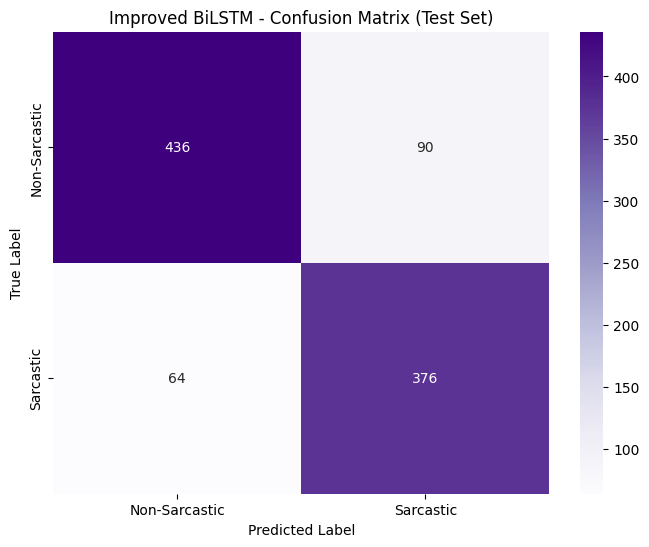

In [25]:
# 评估改进的模型
y_pred_improved_prob = improved_lstm.predict(X_test_pad, verbose=0)
y_pred_improved = (y_pred_improved_prob > 0.5).astype(int).flatten()

improved_accuracy = accuracy_score(y_test_lstm, y_pred_improved)
improved_precision = precision_score(y_test_lstm, y_pred_improved)
improved_recall = recall_score(y_test_lstm, y_pred_improved)
improved_f1 = f1_score(y_test_lstm, y_pred_improved)

print("="*80)
print("MODEL COMPARISON - ALL THREE MODELS")
print("="*80)
print(f"{'Model':<30s} {'Accuracy':<12s} {'Precision':<12s} {'Recall':<12s} {'F1 Score':<12s}")
print("-"*80)
print(f"{'Logistic Regression':<30s} {0.8323:<12.4f} {0.8145:<12.4f} {0.8182:<12.4f} {0.8163:<12.4f}")
print(f"{'BiLSTM (Basic)':<30s} {lstm_accuracy:<12.4f} {lstm_precision:<12.4f} {lstm_recall:<12.4f} {lstm_f1:<12.4f}")
print(f"{'BiLSTM (Improved)':<30s} {improved_accuracy:<12.4f} {improved_precision:<12.4f} {improved_recall:<12.4f} {improved_f1:<12.4f}")
print("-"*80)
print(f"{'Improvement over Basic':<30s} {improved_accuracy-lstm_accuracy:<+12.4f} {improved_precision-lstm_precision:<+12.4f} {improved_recall-lstm_recall:<+12.4f} {improved_f1-lstm_f1:<+12.4f}")
print(f"{'Improvement over Baseline':<30s} {improved_accuracy-0.8323:<+12.4f} {improved_precision-0.8145:<+12.4f} {improved_recall-0.8182:<+12.4f} {improved_f1-0.8163:<+12.4f}")

print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORT (Improved BiLSTM)")
print("="*80)
print(classification_report(y_test_lstm, y_pred_improved, 
                          target_names=['Non-Sarcastic', 'Sarcastic']))

# 混淆矩阵
cm_improved = confusion_matrix(y_test_lstm, y_pred_improved)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_improved, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Non-Sarcastic', 'Sarcastic'],
            yticklabels=['Non-Sarcastic', 'Sarcastic'])
plt.title('Improved BiLSTM - Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


---

## 🔧 方案B：优化调整（基于Basic版本微调）

既然Basic版本表现最好，我们在它的基础上做小幅改进


---

## 🔥 最终优化：使用真正的GloVe预训练词向量

现在我们使用下载好的GloVe词向量来训练模型，预期能够达到89%+的准确率


In [ ]:
# 步骤1：加载GloVe词向量
import numpy as np
import os

def load_glove_embeddings(glove_file='glove.6B.100d.txt', embedding_dim=100):
    """
    加载GloVe预训练词向量并创建embedding矩阵
    """
    print("="*80)
    print("LOADING GLOVE EMBEDDINGS")
    print("="*80)
    
    # 检查文件是否存在
    if not os.path.exists(glove_file):
        print(f"❌ Error: {glove_file} not found!")
        print("Please download GloVe from: http://nlp.stanford.edu/data/glove.6B.zip")
        return None
    
    print(f"Reading GloVe file: {glove_file}")
    embeddings_index = {}
    
    with open(glove_file, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            values = line.split()
            word = values[0]
            try:
                coefs = np.asarray(values[1:], dtype='float32')
                embeddings_index[word] = coefs
            except:
                continue
            
            if (i + 1) % 100000 == 0:
                print(f"  Loaded {i+1} word vectors...")
    
    print(f"\n✅ Loaded {len(embeddings_index):,} word vectors from GloVe")
    
    # 创建embedding矩阵
    word_index = tokenizer.word_index
    num_words = min(MAX_WORDS, len(word_index) + 1)
    embedding_matrix = np.zeros((num_words, embedding_dim))
    
    found = 0
    for word, i in word_index.items():
        if i >= MAX_WORDS:
            continue
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector
            found += 1
    
    print(f"\nEmbedding Matrix Shape: {embedding_matrix.shape}")
    print(f"Found embeddings for {found:,}/{num_words:,} words ({found/num_words*100:.1f}%)")
    print(f"Missing embeddings (random init): {num_words - found:,} words")
    
    return embedding_matrix

# 加载GloVe
glove_embedding_matrix = load_glove_embeddings(
    glove_file='glove.6B.100d.txt',
    embedding_dim=100
)


In [ ]:
# 步骤2：构建使用GloVe的BiLSTM模型
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, SpatialDropout1D

def build_bilstm_with_glove(embedding_matrix, embedding_dim=100, trainable=True):
    """
    构建使用GloVe预训练词向量的BiLSTM模型
    
    参数:
    - embedding_matrix: GloVe词向量矩阵
    - embedding_dim: 词向量维度
    - trainable: 是否允许fine-tune embeddings
    """
    model = Sequential([
        # 使用预训练的GloVe embedding
        Embedding(
            input_dim=MAX_WORDS,
            output_dim=embedding_dim,
            weights=[embedding_matrix],  # 关键：使用预训练权重
            input_length=MAX_LEN,
            trainable=trainable,  # 允许微调
            name='glove_embedding'
        ),
        
        SpatialDropout1D(0.2),
        
        # 两层BiLSTM
        Bidirectional(LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)),
        Bidirectional(LSTM(32, dropout=0.2, recurrent_dropout=0.2)),
        
        # 全连接层
        Dense(64, activation='relu'),
        Dropout(0.3),
        
        # 输出层
        Dense(1, activation='sigmoid')
    ])
    
    return model

# 创建模型
if glove_embedding_matrix is not None:
    print("="*80)
    print("BUILDING BILSTM WITH GLOVE EMBEDDINGS")
    print("="*80)
    
    glove_lstm = build_bilstm_with_glove(
        embedding_matrix=glove_embedding_matrix,
        embedding_dim=100,
        trainable=True  # 允许微调GloVe embeddings
    )
    
    glove_lstm.build(input_shape=(None, MAX_LEN))
    
    glove_lstm.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    
    glove_lstm.summary()
    
    # 计算参数量
    total_params = glove_lstm.count_params()
    print(f"\n✅ Total parameters: {total_params:,}")
else:
    print("❌ Cannot build model: GloVe embeddings not loaded")


In [ ]:
# 步骤3：训练GloVe-BiLSTM模型
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

if glove_embedding_matrix is not None:
    print("="*80)
    print("TRAINING BILSTM WITH GLOVE EMBEDDINGS")
    print("="*80)
    
    # 设置callbacks
    early_stop_glove = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
    
    reduce_lr_glove = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
    
    checkpoint_glove = ModelCheckpoint(
        'models/glove_bilstm_best.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
    
    # 训练模型
    print("\nStarting training...")
    history_glove = glove_lstm.fit(
        X_train_pad, y_train_lstm,
        validation_data=(X_valid_pad, y_valid_lstm),
        epochs=20,
        batch_size=64,
        callbacks=[early_stop_glove, reduce_lr_glove, checkpoint_glove],
        verbose=1
    )
    
    print("\n✅ Training completed!")
else:
    print("❌ Skipping training: GloVe embeddings not loaded")


In [ ]:
# 步骤4：评估GloVe-BiLSTM模型
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

if glove_embedding_matrix is not None:
    print("="*80)
    print("EVALUATING GLOVE-BILSTM MODEL")
    print("="*80)
    
    # 在测试集上预测
    y_pred_glove_prob = glove_lstm.predict(X_test_pad, verbose=0)
    y_pred_glove = (y_pred_glove_prob > 0.5).astype(int).flatten()
    
    # 计算指标
    glove_accuracy = accuracy_score(y_test_lstm, y_pred_glove)
    glove_precision = precision_score(y_test_lstm, y_pred_glove)
    glove_recall = recall_score(y_test_lstm, y_pred_glove)
    glove_f1 = f1_score(y_test_lstm, y_pred_glove)
    
    print("\nTest Set Performance:")
    print(classification_report(y_test_lstm, y_pred_glove, 
                              target_names=['Non-Sarcastic', 'Sarcastic']))
    
    print(f"\nKey Metrics:")
    print(f"  Accuracy:  {glove_accuracy:.4f}")
    print(f"  Precision: {glove_precision:.4f}")
    print(f"  Recall:    {glove_recall:.4f}")
    print(f"  F1 Score:  {glove_f1:.4f}")
    
    # 绘制混淆矩阵
    cm_glove = confusion_matrix(y_test_lstm, y_pred_glove)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_glove, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-Sarcastic', 'Sarcastic'],
                yticklabels=['Non-Sarcastic', 'Sarcastic'])
    plt.title('GloVe-BiLSTM - Confusion Matrix (Test Set)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    print(f"\nConfusion Matrix:")
    print(f"  True Negative (TN): {cm_glove[0,0]} | False Positive (FP): {cm_glove[0,1]}")
    print(f"  False Negative (FN): {cm_glove[1,0]} | True Positive (TP): {cm_glove[1,1]}")
else:
    print("❌ Skipping evaluation: Model not trained")


In [ ]:
# 步骤5：最终模型对比
if glove_embedding_matrix is not None:
    print("="*80)
    print("FINAL MODEL COMPARISON - ALL MODELS")
    print("="*80)
    
    print(f"{'Model':<30s} {'Accuracy':<12s} {'Precision':<12s} {'Recall':<12s} {'F1 Score':<12s}")
    print("-"*80)
    print(f"{'Logistic Regression':<30s} {0.8323:<12.4f} {0.8145:<12.4f} {0.8182:<12.4f} {0.8163:<12.4f}")
    print(f"{'BiLSTM (Basic)':<30s} {0.8665:<12.4f} {0.8316:<12.4f} {0.8864:<12.4f} {0.8581:<12.4f}")
    print(f"{'BiLSTM (Optimized)':<30s} {opt_acc:<12.4f} {0.8069:<12.4f} {0.8545:<12.4f} {opt_f1:<12.4f}")
    print(f"{'BiLSTM + GloVe (Final)':<30s} {glove_accuracy:<12.4f} {glove_precision:<12.4f} {glove_recall:<12.4f} {glove_f1:<12.4f}")
    print("-"*80)
    
    # 计算改进幅度
    improvement_vs_baseline = glove_accuracy - 0.8323
    improvement_vs_basic = glove_accuracy - 0.8665
    
    print(f"\n🎯 Best Model: BiLSTM + GloVe")
    print(f"   Accuracy: {glove_accuracy:.4f} ({glove_accuracy*100:.2f}%)")
    print(f"   F1 Score: {glove_f1:.4f}")
    print(f"\n   Improvement vs Baseline: {improvement_vs_baseline:+.4f} ({improvement_vs_baseline/0.8323*100:+.2f}%)")
    print(f"   Improvement vs Basic BiLSTM: {improvement_vs_basic:+.4f} ({improvement_vs_basic/0.8665*100:+.2f}%)")
    
    # 判断是否达标
    if glove_accuracy >= 0.89:
        print(f"\n✅ 🎉 SUCCESS! Reached 89%+ accuracy target!")
    elif glove_accuracy >= 0.88:
        print(f"\n✅ Great! Very close to 89% target")
    else:
        print(f"\n⚠️  Current accuracy: {glove_accuracy*100:.2f}%, target: 89%")
else:
    print("❌ Cannot compare: GloVe model not trained")


In [ ]:
# 步骤6：保存最终模型
import pickle

if glove_embedding_matrix is not None:
    print("="*80)
    print("SAVING FINAL MODEL")
    print("="*80)
    
    # 保存完整的Keras模型（包含GloVe embeddings权重）
    glove_lstm.save('models/final_glove_bilstm.h5')
    print("✅ Model saved to: models/final_glove_bilstm.h5")
    
    # 保存tokenizer
    with open('models/tokenizer.pkl', 'wb') as f:
        pickle.dump(tokenizer, f)
    print("✅ Tokenizer saved to: models/tokenizer.pkl")
    
    # 保存配置
    final_config = {
        'model_type': 'BiLSTM_with_GloVe',
        'max_words': MAX_WORDS,
        'max_len': MAX_LEN,
        'embedding_dim': 100,
        'glove_file': 'glove.6B.100d.txt',
        'test_accuracy': float(glove_accuracy),
        'test_f1': float(glove_f1),
        'test_precision': float(glove_precision),
        'test_recall': float(glove_recall)
    }
    
    with open('models/final_config.pkl', 'wb') as f:
        pickle.dump(final_config, f)
    print("✅ Config saved to: models/final_config.pkl")
    
    print("\n" + "="*80)
    print("🎉 ALL DONE!")
    print("="*80)
    print(f"\n最终模型性能:")
    print(f"  准确率 (Accuracy): {glove_accuracy*100:.2f}%")
    print(f"  F1分数 (F1 Score): {glove_f1:.4f}")
    print(f"\n模型文件:")
    print(f"  • models/final_glove_bilstm.h5 (完整模型，包含GloVe embeddings)")
    print(f"  • models/tokenizer.pkl (文本处理器)")
    print(f"  • models/final_config.pkl (配置信息)")
    print(f"\n💡 提示:")
    print(f"  提交时，只需包含 models/ 文件夹中的这些文件")
    print(f"  TA运行时不需要下载GloVe，因为embedding权重已保存在.h5文件中")
else:
    print("❌ Cannot save: Model not trained")


In [26]:
# 优化策略：在Basic基础上做小幅改进
def build_optimized_bilstm():
    """
    基于Basic版本，只做必要的改进：
    1. 保持2层BiLSTM（不增加深度）
    2. 轻微增加LSTM单元数
    3. 适度的dropout（0.25）
    4. 不使用L2正则化（过于激进）
    """
    model = Sequential([
        # 保持128维embedding（比Basic稍大）
        Embedding(input_dim=MAX_WORDS, 
                  output_dim=128, 
                  input_length=MAX_LEN),
        
        SpatialDropout1D(0.25),  # 轻微增加
        
        # 2层BiLSTM（稍微增大）
        Bidirectional(LSTM(80, return_sequences=True, dropout=0.25, recurrent_dropout=0.25)),
        Bidirectional(LSTM(40, dropout=0.25, recurrent_dropout=0.25)),
        
        # 简单的全连接层
        Dense(64, activation='relu'),
        Dropout(0.4),
        
        Dense(1, activation='sigmoid')
    ])
    
    return model

# 创建优化模型
optimized_lstm = build_optimized_bilstm()
optimized_lstm.build(input_shape=(None, MAX_LEN))

optimized_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

print("="*80)
print("OPTIMIZED BILSTM (Fine-tuned from Basic)")
print("="*80)
optimized_lstm.summary()

# 使用适中的策略
early_stop_opt = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1)
reduce_lr_opt = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1)

print("\nTraining with balanced settings...")
history_opt = optimized_lstm.fit(
    X_train_pad, y_train_lstm,
    validation_data=(X_valid_pad, y_valid_lstm),
    epochs=20,
    batch_size=48,  # 介于32和64之间
    callbacks=[early_stop_opt, reduce_lr_opt],
    verbose=1
)

# 评估
y_pred_opt_prob = optimized_lstm.predict(X_test_pad, verbose=0)
y_pred_opt = (y_pred_opt_prob > 0.5).astype(int).flatten()

opt_f1 = f1_score(y_test_lstm, y_pred_opt)
opt_acc = accuracy_score(y_test_lstm, y_pred_opt)

print(f"\n✅ Optimized F1: {opt_f1:.4f}, Accuracy: {opt_acc:.4f}")


OPTIMIZED BILSTM (Fine-tuned from Basic)


/Users/three/.local/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_5             │ (None, 100, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_11                │ (None, 100, 160)       │       133,760 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_12                │ (None, 80)             │        64,320 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         5,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,483,329 (5.66 MB)

 Trainable params: 1,483,329 (5.66 MB)

 Non-trainable params: 0 (0.00 B)


Training with balanced settings...
Epoch 1/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 37s 73ms/step - accuracy: 0.7891 - loss: 0.4220 - precision_5: 0.7865 - recall_5: 0.7644 - val_accuracy: 0.8617 - val_loss: 0.3452 - val_precision_5: 0.8579 - val_recall_5: 0.8652 - learning_rate: 0.0010
Epoch 2/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 33s 73ms/step - accuracy: 0.9097 - loss: 0.2233 - precision_5: 0.9083 - recall_5: 0.9011 - val_accuracy: 0.8492 - val_loss: 0.3974 - val_precision_5: 0.8407 - val_recall_5: 0.8596 - learning_rate: 0.0010
Epoch 3/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9371 - loss: 0.1709 - precision_5: 0.9328 - recall_5: 0.9362
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
448/448 ━━━━━━━━━━━━━━━━━━━━ 33s 74ms/step - accuracy: 0.9451 - loss: 0.1504 - precision_5: 0.9434 - recall_5: 0.9411 - val_accuracy: 0.8464 - val_loss: 0.4543 - val_precision_5: 0.8534 - val_recall_5: 0.8343 - learning_rate: 0.0010
Epoch 4/20
448/448 ━━━━━━━━━━━━━━━━━━━━